<a href="https://colab.research.google.com/github/andilMc/gemmafro-e2b/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Analyse exploratoire des données (Phase 1)

Correspond à la Phase 1 de `docs/WORKFLOW.md`. Peut se lancer indépendamment de `00_setup_environment.ipynb` (pas besoin de GPU ni du modèle complet — seulement le tokenizer).

## 1 — Récupérer le dépôt et charger les données

In [1]:
import os

REPO_DIR = '/content/gemmafro-e2b'
if not os.path.isdir(REPO_DIR):
    !git clone https://github.com/andilMc/gemmafro-e2b.git {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

DATA_DIR = f'{REPO_DIR}/data'

Cloning into '/content/gemmafro-e2b'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 57 (delta 23), reused 37 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 5.93 MiB | 12.67 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [3]:
!pip install -q -U pandas matplotlib transformers sentencepiece

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv(f'{DATA_DIR}/Train.csv')
val   = pd.read_csv(f'{DATA_DIR}/Val.csv')
test  = pd.read_csv(f'{DATA_DIR}/Test.csv')

print('Train:', train.shape, '| Val:', val.shape, '| Test:', test.shape)
train.head(3)

Train: (29815, 4) | Val: (6686, 4) | Test: (2618, 3)


,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a...,Mmabun betumi aboa atipɛnfo a ebia nsa anaa nn...,Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu...,"Wɔ Ghana mu no, amanmmra no gye binary gender ...",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔ...,Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔ...,Aka_Gha


## 2 — Types, valeurs manquantes, doublons d'ID

In [5]:
for name, df in [('Train', train), ('Val', val), ('Test', test)]:
    print(f'--- {name} ---')
    print(df.dtypes)
    print('Valeurs manquantes :')
    print(df.isna().sum())
    print(f"IDs dupliqués : {df['ID'].duplicated().sum()}")
    print()

--- Train ---
ID        str
input     str
output    str
subset    str
dtype: object
Valeurs manquantes :
ID        0
input     0
output    0
subset    0
dtype: int64
IDs dupliqués : 0

--- Val ---
ID        str
input     str
output    str
subset    str
dtype: object
Valeurs manquantes :
ID        0
input     0
output    0
subset    0
dtype: int64
IDs dupliqués : 0

--- Test ---
ID        str
input     str
subset    str
dtype: object
Valeurs manquantes :
ID        0
input     0
subset    0
dtype: int64
IDs dupliqués : 0



## 3 — Distribution par langue (`subset`)
Déjà identifiée comme déséquilibrée (cf. `docs/PROJET.md` / `docs/WORKFLOW.md`) : à confirmer précisément ici avant de décider d'un éventuel rééquilibrage en Phase 2.

In [6]:
langs = sorted(train['subset'].unique())

dist = pd.DataFrame({
    'train': train['subset'].value_counts().reindex(langs),
    'val':   val['subset'].value_counts().reindex(langs),
    'test':  test['subset'].value_counts().reindex(langs),
})
dist['train_pct'] = (dist['train'] / dist['train'].sum() * 100).round(1)
dist.sort_values('train', ascending=False)

,train,val,test,train_pct
subset,,,,
Eng_Uga,7624,1688,744,25.6
Aka_Gha,4455,1114,492,14.9
Eng_Gha,4443,1104,491,14.9
Eng_Eth,3915,564,60,13.1
Lug_Uga,3383,846,374,11.3
Eng_Ken,2080,390,167,7.0
Swa_Ken,2070,518,229,6.9
Amh_Eth,1845,462,61,6.2


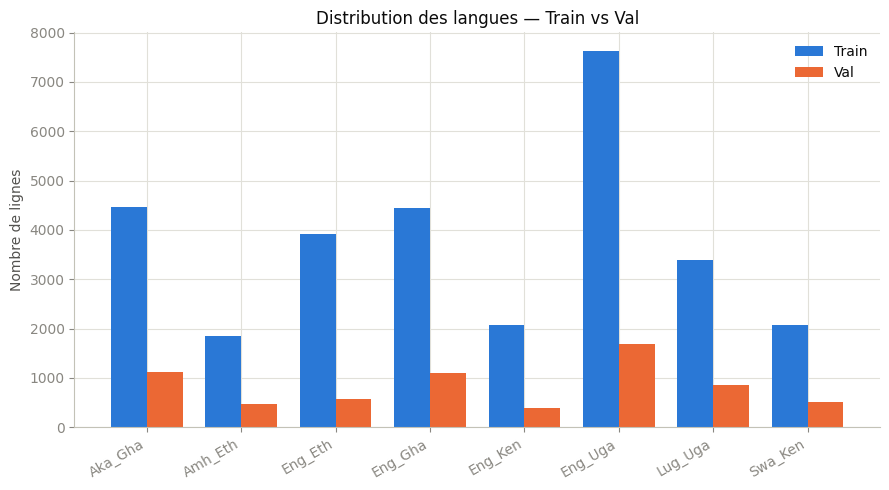

In [7]:
# Style commun aux graphiques du notebook : marques fines, grille discrète, pas de doubles axes.
plt.rcParams.update({
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': '#52514e',
    'text.color': '#0b0b0b',
    'xtick.color': '#898781',
    'ytick.color': '#898781',
    'axes.grid': True,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True,
})

x = range(len(langs))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - width/2 for i in x], dist['train'].values, width, label='Train', color='#2a78d6')
ax.bar([i + width/2 for i in x], dist['val'].values, width, label='Val', color='#eb6834')
ax.set_xticks(list(x))
ax.set_xticklabels(langs, rotation=30, ha='right')
ax.set_ylabel('Nombre de lignes')
ax.set_title('Distribution des langues — Train vs Val')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 4 — Tokenisation par langue (tokenizer Gemma)
Longueur des questions/réponses en tokens, et efficacité de la tokenisation (tokens/mot) par langue — un ratio élevé signale une faible couverture de la langue dans le pré-entraînement du tokenizer.

⚠️ Nécessite un token Hugging Face avec la licence Gemma acceptée (cf. `docs/WORKFLOW.md`, Phase 0, étapes 9-11).

In [8]:
from google.colab import userdata
from huggingface_hub import login
from transformers import AutoTokenizer

login(token=userdata.get('HF_TOKEN'))

MODEL_NAME = "google/gemma-4-E2B-it"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.08k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 32.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/18.6k [00:00<?, ?B/s]

In [9]:
def batch_token_lengths(texts, tokenizer, batch_size=256):
    lengths = []
    texts = [str(t) for t in texts]
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(batch, add_special_tokens=False)
        lengths.extend(len(ids) for ids in enc['input_ids'])
    return lengths

train['input_tokens']  = batch_token_lengths(train['input'], tokenizer)
train['output_tokens'] = batch_token_lengths(train['output'], tokenizer)

token_stats = train.groupby('subset')[['input_tokens', 'output_tokens']].agg(['mean', 'median', 'max']).round(1)
token_stats.reindex(langs)

input_tokens             output_tokens             
                mean median  max          mean median   max
subset                                                     
Aka_Gha         62.2   58.0  190         233.4  216.0   997
Amh_Eth         28.0   27.0   75          59.6   57.0   306
Eng_Eth         14.5   14.0   35          32.2   31.0   138
Eng_Gha         23.3   22.0   57          93.4   86.0   519
Eng_Ken         13.4   12.0   59          96.7   79.0   399
Eng_Uga         14.0   14.0  106         120.9   95.0   636
Lug_Uga         31.4   30.0  119         245.2  206.0  1060
Swa_Ken         23.9   23.0   94         175.2  138.0   721

/tmp/ipykernel_3451/1659421834.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(langs, rotation=30, ha='right')


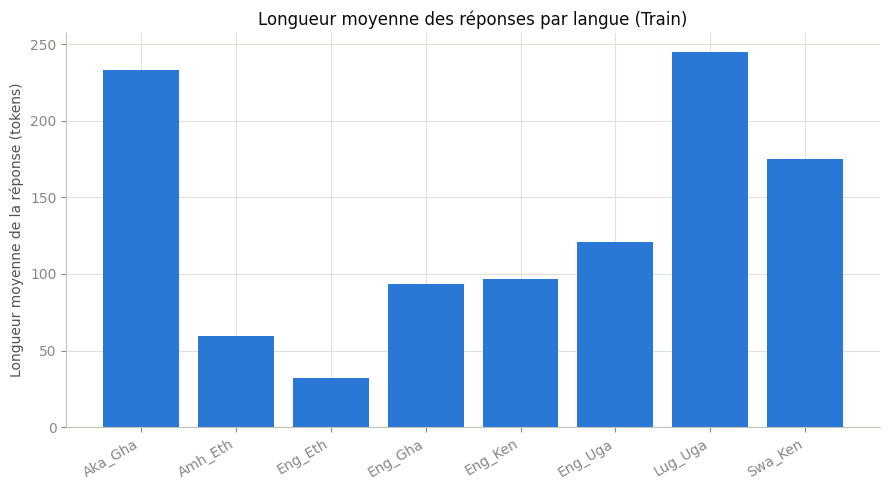

In [10]:
mean_len = train.groupby('subset')['output_tokens'].mean().reindex(langs)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(langs, mean_len.values, color='#2a78d6')
ax.set_xticklabels(langs, rotation=30, ha='right')
ax.set_ylabel('Longueur moyenne de la réponse (tokens)')
ax.set_title('Longueur moyenne des réponses par langue (Train)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3451/3414441809.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tok_ratio.index, rotation=30, ha='right')


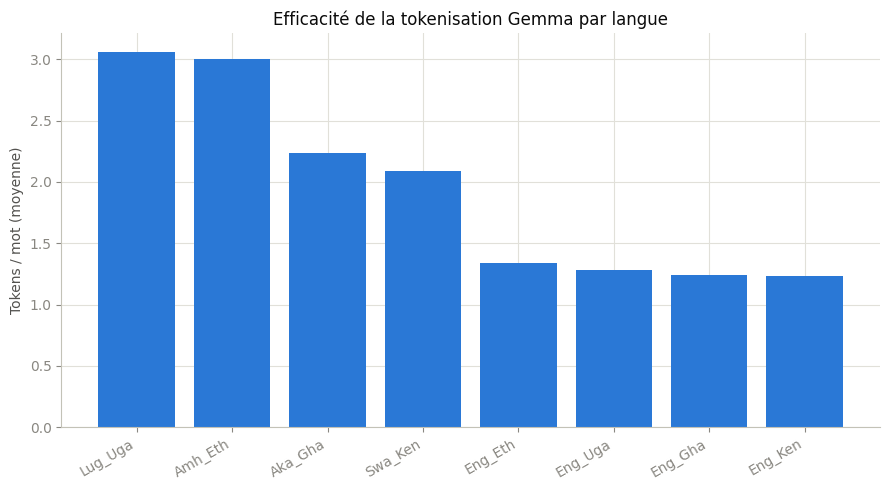

subset
Lug_Uga    3.063291
Amh_Eth    3.006745
Aka_Gha    2.235968
Swa_Ken    2.086828
Eng_Eth    1.337401
Eng_Uga    1.282601
Eng_Gha    1.243184
Eng_Ken    1.231819
Name: tokens_per_word, dtype: float64

In [11]:
# Tokens/mot : un ratio élevé = tokenizer qui fragmente beaucoup la langue (peu vue au pré-entraînement).
train['output_words'] = train['output'].str.split().str.len().clip(lower=1)
train['tokens_per_word'] = train['output_tokens'] / train['output_words']

tok_ratio = train.groupby('subset')['tokens_per_word'].mean().reindex(langs).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(tok_ratio.index, tok_ratio.values, color='#2a78d6')
ax.set_xticklabels(tok_ratio.index, rotation=30, ha='right')
ax.set_ylabel('Tokens / mot (moyenne)')
ax.set_title("Efficacité de la tokenisation Gemma par langue")
plt.tight_layout()
plt.show()

tok_ratio

## 5 — Réponses dupliquées / "template"
Repère les réponses très courtes ou très répétées (ex. "Yes"/"No"/"Ndiyo"/"Hapana") qui pourraient fausser l'entraînement si elles sont sur-représentées.

In [12]:
dup_count = train['output'].duplicated().sum()
print(f"Réponses dupliquées dans Train : {dup_count} ({dup_count / len(train):.1%})")

print('\nTop 5 réponses les plus fréquentes par langue :')
top_answers = (
    train.groupby('subset')['output']
    .value_counts()
    .groupby(level=0, group_keys=False)
    .head(5)
)
top_answers

Réponses dupliquées dans Train : 11737 (39.4%)

Top 5 réponses les plus fréquentes par langue :


subset   output                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

## 6 — Synthèse et décisions pour la Phase 2

À compléter après lecture des résultats ci-dessus :

- **Déséquilibre des langues** : ampleur exacte confirmée en section 3 → décider d'un sur-échantillonnage / pondération de la perte par langue.
- **Longueur des séquences** : `MAX_INPUT_LENGTH` / `MAX_OUTPUT_LENGTH` à fixer en Phase 2-3 à partir des percentiles observés en section 4 (éviter de tronquer trop de réponses, surtout pour les langues aux séquences plus longues).
- **Efficacité de tokenisation** : langues avec un ratio tokens/mot élevé (section 4) demanderont probablement plus d'epochs ou un `max_new_tokens` plus généreux à l'inférence.
- **Réponses "template"** : décider si les réponses très courtes/dupliquées identifiées en section 5 doivent être filtrées, sous-échantillonnées, ou conservées telles quelles.